## 1. Setup & Data Loading

In [1]:
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Data handling
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.dates as mdates

# Machine learning
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)
from sklearn.pipeline import Pipeline

print('All libraries imported successfully.')

All libraries imported successfully.


In [2]:
!unzip -q 'patient data.zip'
print('Dataset extracted.')

Dataset extracted.


In [3]:
# Single, complete file-path registry — all 5 signal types for all 5 patients.
PATIENT_FILE_PATHS = {
    'AP01': {
        'Nasal Airflow':             'AP01/Flow - 30-05-2024.txt',
        'Thoracic Movement':         'AP01/Thorac - 30-05-2024.txt',
        'SPO2':                      'AP01/SPO2 - 30-05-2024.txt',
        'Breathing Irregularities':  'AP01/Flow Events - 30-05-2024.txt',
        'Sleep Profile':             'AP01/Sleep profile - 30-05-2024.txt',
    },
    'AP02': {
        'Nasal Airflow':             'AP02/Flow  - 30.05.2024.txt',
        'Thoracic Movement':         'AP02/Thorac  - 30.05.2024.txt',
        'SPO2':                      'AP02/SPO2  - 30.05.2024.txt',
        'Breathing Irregularities':  'AP02/Flow Events  - 30.05.2024.txt',
        'Sleep Profile':             'AP02/Sleep profile  - 30.05.2024.txt',
    },
    'AP03': {
        'Nasal Airflow':             'AP03/Flow - 29_05_2024.txt',
        'Thoracic Movement':         'AP03/Thorac - 29_05_2024.txt',
        'SPO2':                      'AP03/SPO2 - 29_05_2024.txt',
        'Breathing Irregularities':  'AP03/Flow Events - 29_05_2024.txt',
        'Sleep Profile':             'AP03/Sleep profile - 29_05_2024.txt',
    },
    'AP04': {
        'Nasal Airflow':             'AP04/Flow Signal - 29.05.2024.txt',
        'Thoracic Movement':         'AP04/Thorac Signal - 29.05.2024.txt',
        'SPO2':                      'AP04/SPO2 Signal - 29.05.2024.txt',
        'Breathing Irregularities':  'AP04/Flow Events - 29.05.2024.txt',
        'Sleep Profile':             'AP04/Sleep profile - 29.05.2024.txt',
    },
    'AP05': {
        'Nasal Airflow':             'AP05/Flow Nasal - 28.05.2024.txt',
        'Thoracic Movement':         'AP05/Thorac Movement - 28.05.2024.txt',
        'SPO2':                      'AP05/SPO2 - 28.05.2024.txt',
        'Breathing Irregularities':  'AP05/Flow Events - 28.05.2024.txt',
        'Sleep Profile':             'AP05/Sleep profile - 28.05.2024.txt',
    },
}

PATIENT_IDS = list(PATIENT_FILE_PATHS.keys())
print(f'Registered {len(PATIENT_IDS)} patients: {PATIENT_IDS}')

Registered 5 patients: ['AP01', 'AP02', 'AP03', 'AP04', 'AP05']


## 2. Data Parsing

### File Format Summary

**Continuous signals** (Nasal Airflow, Thoracic Movement, SpO₂):  
Header fields (`Signal Type`, `Start Time`, `Sample Rate`, `Length`, `Unit`) followed by a `Data:` marker, then rows of `DD.MM.YYYY HH:MM:SS,mmm; value`.

**Breathing Irregularities** (event-based):  
Header fields (`Signal ID`, `Start Time`, `Unit`, `Signal Type`) then rows of:  
`DD.MM.YYYY HH:MM:SS,mmm-HH:MM:SS,mmm; duration_s; EventType; SleepStage`  
Note: the end-time field contains only the time portion (no date), so the date must be inherited from the start-time.

**Sleep Profile** (discrete epochs):  
Header includes `Events list` and `Rate: 30 s`; data starts after the `Rate:` line.  
Rows: `DD.MM.YYYY HH:MM:SS,mmm; SleepStage`.  
Known stages: `N4, N3, N2, N1, REM, Wake, Movement`.  
Stage `A` (Arousal) appears in several participants — treated as a distinct valid stage.

In [4]:
def parse_continuous_signal(file_path: str) -> tuple[pd.DataFrame, dict]:
    header_info = {}
    data_rows   = []
    in_data     = False

    with open(file_path, 'r') as fh:
        for raw in fh:
            line = raw.strip()
            if not line:
                continue

            if line == 'Data:':
                in_data = True
                continue

            if not in_data:
                if ':' in line:
                    key, val = line.split(':', 1)
                    header_info[key.strip()] = val.strip()
            else:
                parts = line.split(';')
                if len(parts) != 2:
                    continue
                ts_str   = parts[0].strip().replace(',', '.')  # normalise millisecond separator
                val_str  = parts[1].strip()
                try:
                    dt  = datetime.strptime(ts_str, '%d.%m.%Y %H:%M:%S.%f')
                    val = float(val_str)
                    data_rows.append((dt, val))
                except ValueError:
                    # Skip rows that cannot be parsed; log count at the end.
                    continue

    df = pd.DataFrame(data_rows, columns=['Timestamp', 'Value'])
    if not df.empty:
        df.set_index('Timestamp', inplace=True)

    return df, header_info

print('parse_continuous_signal defined.')

parse_continuous_signal defined.


In [5]:
def parse_breathing_events(file_path: str) -> pd.DataFrame:
    HEADER_KEYS = {'Signal ID:', 'Start Time:', 'Unit:', 'Signal Type:'}
    in_data  = False
    rows     = []
    skipped  = 0

    with open(file_path, 'r') as fh:
        for raw in fh:
            line = raw.strip()
            if not line:
                continue

            # Switch to data mode once we pass all known header lines
            if not in_data and not any(line.startswith(h) for h in HEADER_KEYS):
                in_data = True

            if not in_data:
                continue

            parts = line.split(';')
            if len(parts) != 4:
                continue

            time_range, dur_str, event_type, stage = [p.strip() for p in parts]

            # Split 'DD.MM.YYYY HH:MM:SS,mmm-HH:MM:SS,mmm'
            if '-' not in time_range:
                skipped += 1
                continue
            start_str, end_str = time_range.split('-', 1)

            try:
                start_dt = datetime.strptime(
                    start_str.strip().replace(',', '.'), '%d.%m.%Y %H:%M:%S.%f'
                )
                # End-time carries only HH:MM:SS,mmm — prepend the start date
                end_str_full = start_dt.strftime('%d.%m.%Y') + ' ' + end_str.strip()
                end_dt = datetime.strptime(
                    end_str_full.replace(',', '.'), '%d.%m.%Y %H:%M:%S.%f'
                )
                duration_annotated = float(dur_str)
                duration_computed  = (end_dt - start_dt).total_seconds()

                rows.append({
                    'Start Timestamp':    start_dt,
                    'End Timestamp':      end_dt,
                    'Duration (s)':       duration_annotated,
                    'Computed Duration (s)': duration_computed,
                    'Event Type':         event_type,
                    'Stage':              stage,
                })
            except ValueError:
                skipped += 1

    if skipped:
        print(f'  [parse_breathing_events] {skipped} rows skipped in {file_path}')

    return pd.DataFrame(rows)

print('parse_breathing_events defined.')

parse_breathing_events defined.


In [6]:
def parse_sleep_profile(file_path: str) -> pd.DataFrame:
    DOCUMENTED_STAGES = {'N4', 'N3', 'N2', 'N1', 'REM', 'Wake', 'Movement'}
    EXTRA_STAGES      = {'A'}  # Arousal — observed but not in header Events list

    in_data  = False
    rows     = []
    unknown  = set()

    with open(file_path, 'r') as fh:
        for raw in fh:
            line = raw.strip()
            if not line:
                continue

            if 'Rate:' in line:
                in_data = True
                continue

            if not in_data:
                continue

            parts = line.split(';')
            if len(parts) != 2:
                continue

            ts_str = parts[0].strip().replace(',', '.')
            stage  = parts[1].strip()

            if stage not in DOCUMENTED_STAGES | EXTRA_STAGES:
                unknown.add(stage)

            try:
                dt = datetime.strptime(ts_str, '%d.%m.%Y %H:%M:%S.%f')
                rows.append({'Timestamp': dt, 'Sleep Stage': stage})
            except ValueError:
                continue

    if unknown:
        print(f'  [parse_sleep_profile] Unexpected stages found in {file_path}: {unknown}')

    df = pd.DataFrame(rows)
    if not df.empty:
        df.set_index('Timestamp', inplace=True)
    return df

print('parse_sleep_profile defined.')

parse_sleep_profile defined.


In [7]:
# Load all data into structured dicts — one entry per patient per signal type.
nasal_data    = {}
thorac_data   = {}
spo2_data     = {}
event_data    = {}
sleep_data    = {}
signal_meta   = {}  # store header metadata (sample rate, length, etc.)

for pid in PATIENT_IDS:
    print(f'Loading {pid} ...', end=' ')
    paths = PATIENT_FILE_PATHS[pid]

    nasal_df,  nasal_hdr  = parse_continuous_signal(paths['Nasal Airflow'])
    thorac_df, thorac_hdr = parse_continuous_signal(paths['Thoracic Movement'])
    spo2_df,   spo2_hdr   = parse_continuous_signal(paths['SPO2'])

    nasal_data[pid]  = nasal_df
    thorac_data[pid] = thorac_df
    spo2_data[pid]   = spo2_df
    signal_meta[pid] = {
        'nasal':  nasal_hdr,
        'thorac': thorac_hdr,
        'spo2':   spo2_hdr,
    }

    event_data[pid] = parse_breathing_events(paths['Breathing Irregularities'])
    sleep_data[pid] = parse_sleep_profile(paths['Sleep Profile'])

    print('done.')

print('\nAll files loaded.')

Loading AP01 ... done.
Loading AP02 ... done.
Loading AP03 ... done.
Loading AP04 ... done.
Loading AP05 ... done.

All files loaded.


## 3. Data Quality Checks

In [8]:
print('=' * 70)
print('DATA QUALITY REPORT')
print('=' * 70)

EXPECTED_DURATION_H = 8
EXPECTED_FS_NASAL   = 32   # Hz
EXPECTED_FS_THORAC  = 32   # Hz
EXPECTED_FS_SPO2    = 4    # Hz

quality_rows = []

for pid in PATIENT_IDS:
    print(f'\n--- {pid} ---')

    # --- Continuous signals ---
    for label, df, hdr, expected_fs in [
        ('Nasal Airflow',     nasal_data[pid],  signal_meta[pid]['nasal'],  EXPECTED_FS_NASAL),
        ('Thoracic Movement', thorac_data[pid], signal_meta[pid]['thorac'], EXPECTED_FS_THORAC),
        ('SPO2',              spo2_data[pid],   signal_meta[pid]['spo2'],   EXPECTED_FS_SPO2),
    ]:
        n_rows       = len(df)
        n_nan        = df['Value'].isna().sum()
        actual_fs    = float(hdr.get('Sample Rate', 0))
        duration_h   = n_rows / (actual_fs * 3600) if actual_fs else 0
        fs_ok        = actual_fs == expected_fs
        nan_pct      = 100 * n_nan / n_rows if n_rows else 0

        print(f'  {label}: {n_rows:>8} rows | '
              f'Fs={actual_fs} Hz {"OK" if fs_ok else "MISMATCH"} | '
              f'Duration≈{duration_h:.2f}h | '
              f'NaN={n_nan} ({nan_pct:.2f}%)')

        quality_rows.append({
            'Patient': pid, 'Signal': label,
            'Rows': n_rows, 'Sample Rate': actual_fs,
            'Duration (h)': round(duration_h, 2),
            'NaN Count': n_nan, 'NaN %': round(nan_pct, 3),
            'FS Match': fs_ok,
        })

    # --- Breathing events ---
    ev = event_data[pid]
    duration_discrepancy = (ev['Computed Duration (s)'] - ev['Duration (s)']).abs()
    n_discrepant = (duration_discrepancy > 1).sum()  # >1 s difference
    print(f'  Breathing Events: {len(ev)} events | '
          f'Duration discrepancies (>1s): {n_discrepant}')

    # --- Sleep profile ---
    sp = sleep_data[pid]
    stages_found = sp['Sleep Stage'].unique().tolist()
    extra = [s for s in stages_found if s not in {'N4','N3','N2','N1','REM','Wake','Movement'}]
    print(f'  Sleep Profile:    {len(sp)} epochs | Stages: {sorted(stages_found)}'
          + (f' | Extra stages: {extra}' if extra else ''))

print('\n' + '=' * 70)
quality_df = pd.DataFrame(quality_rows)
print('\nSummary table:')
print(quality_df.to_string(index=False))

DATA QUALITY REPORT

--- AP01 ---
  Nasal Airflow:   875184 rows | Fs=32.0 Hz OK | Duration≈7.60h | NaN=0 (0.00%)
  Thoracic Movement:   875184 rows | Fs=32.0 Hz OK | Duration≈7.60h | NaN=0 (0.00%)
  SPO2:   109398 rows | Fs=4.0 Hz OK | Duration≈7.60h | NaN=0 (0.00%)
  Breathing Events: 161 events | Duration discrepancies (>1s): 0
  Sleep Profile:    912 epochs | Stages: ['N1', 'N2', 'N3', 'REM', 'Wake']

--- AP02 ---
  Nasal Airflow:   849672 rows | Fs=32.0 Hz OK | Duration≈7.38h | NaN=0 (0.00%)
  Thoracic Movement:   849672 rows | Fs=32.0 Hz OK | Duration≈7.38h | NaN=0 (0.00%)
  SPO2:   106209 rows | Fs=4.0 Hz OK | Duration≈7.38h | NaN=0 (0.00%)
  Breathing Events: 186 events | Duration discrepancies (>1s): 0
  Sleep Profile:    886 epochs | Stages: ['A', 'Movement', 'N1', 'N2', 'N3', 'REM', 'Wake'] | Extra stages: ['A']

--- AP03 ---
  Nasal Airflow:   814593 rows | Fs=32.0 Hz OK | Duration≈7.07h | NaN=0 (0.00%)
  Thoracic Movement:   814593 rows | Fs=32.0 Hz OK | Duration≈7.07h | N

## 4. Exploratory Data Analysis

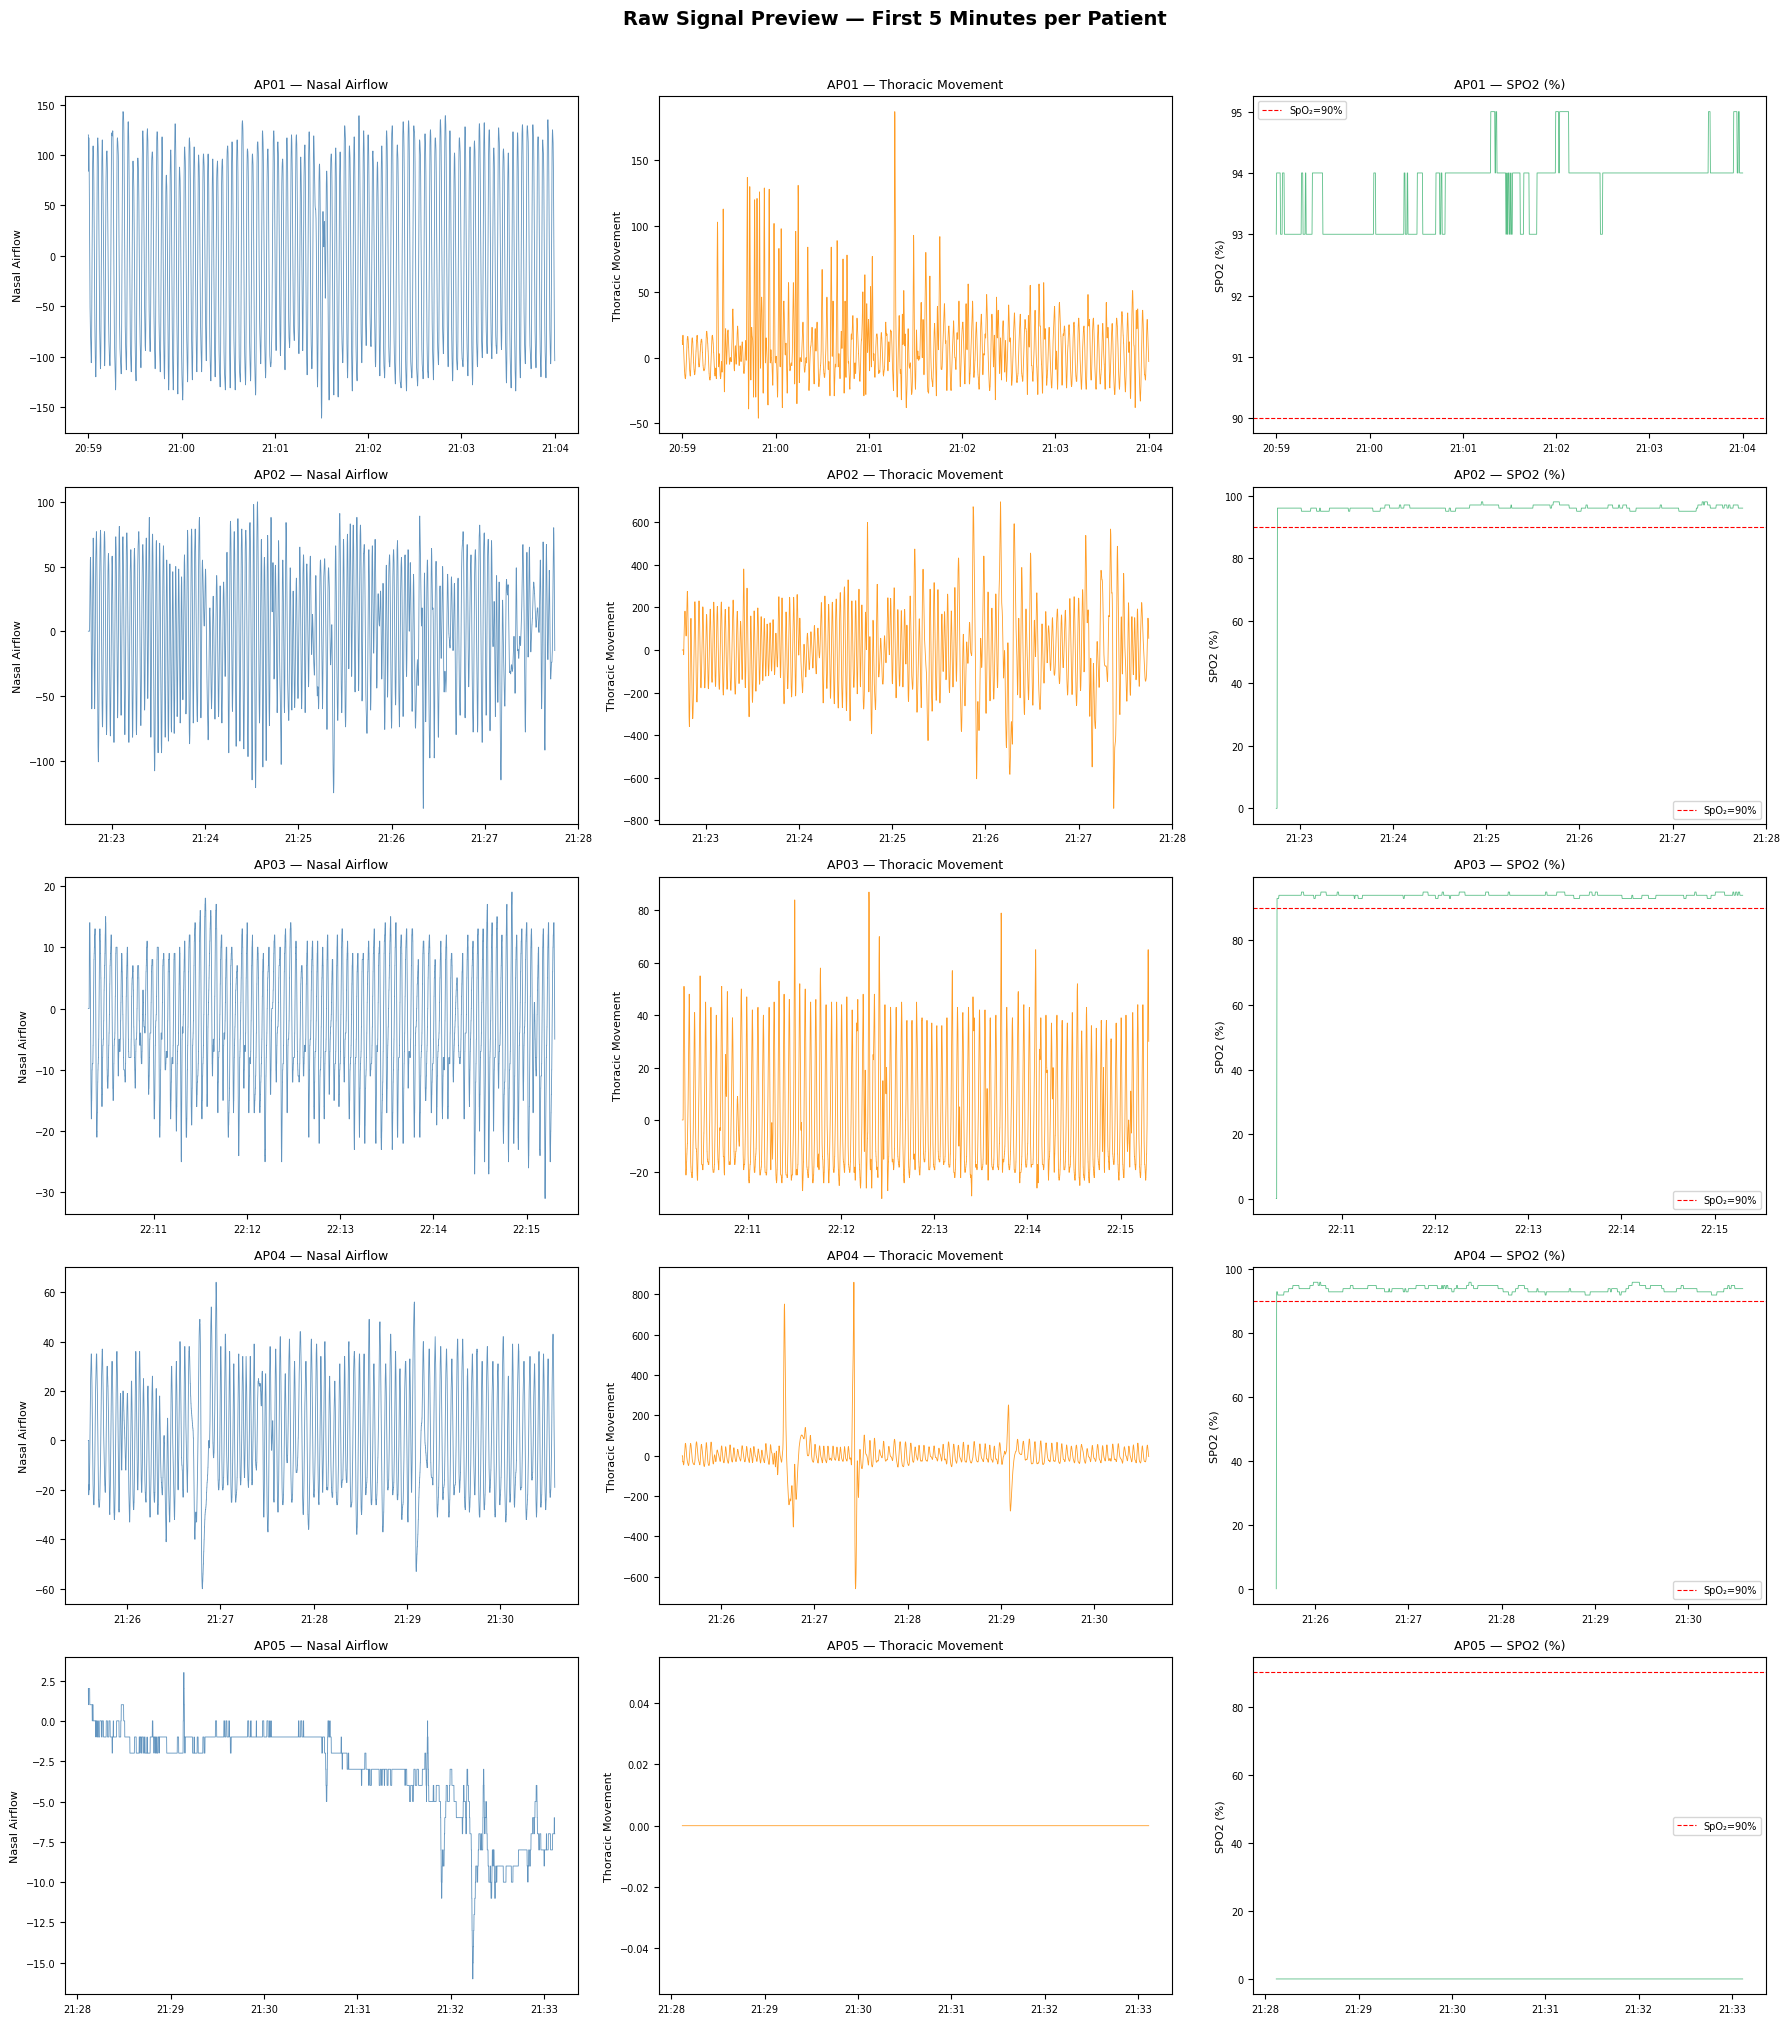

Figure saved: eda_raw_signals.png


In [9]:
# 4a. Raw signal preview (first 5 minutes)

PREVIEW_MINUTES = 5

fig, axes = plt.subplots(len(PATIENT_IDS), 3, figsize=(18, 4 * len(PATIENT_IDS)),
                         sharex=False)
fig.suptitle(f'Raw Signal Preview — First {PREVIEW_MINUTES} Minutes per Patient',
             fontsize=14, fontweight='bold', y=1.01)

for row_idx, pid in enumerate(PATIENT_IDS):
    for col_idx, (label, df, colour) in enumerate([
        ('Nasal Airflow',     nasal_data[pid],  'steelblue'),
        ('Thoracic Movement', thorac_data[pid], 'darkorange'),
        ('SPO2 (%)',          spo2_data[pid],   'mediumseagreen'),
    ]):
        ax = axes[row_idx, col_idx]
        start = df.index[0]
        end   = start + pd.Timedelta(minutes=PREVIEW_MINUTES)
        subset = df.loc[start:end, 'Value']
        ax.plot(subset.index, subset.values, color=colour, linewidth=0.6, alpha=0.85)
        ax.set_title(f'{pid} — {label}', fontsize=9)
        ax.set_ylabel(label, fontsize=8)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
        ax.tick_params(axis='x', labelsize=7)
        ax.tick_params(axis='y', labelsize=7)
        if label == 'SPO2 (%)':
            ax.axhline(90, color='red', linewidth=0.8, linestyle='--', label='SpO₂=90%')
            ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig('eda_raw_signals.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: eda_raw_signals.png')

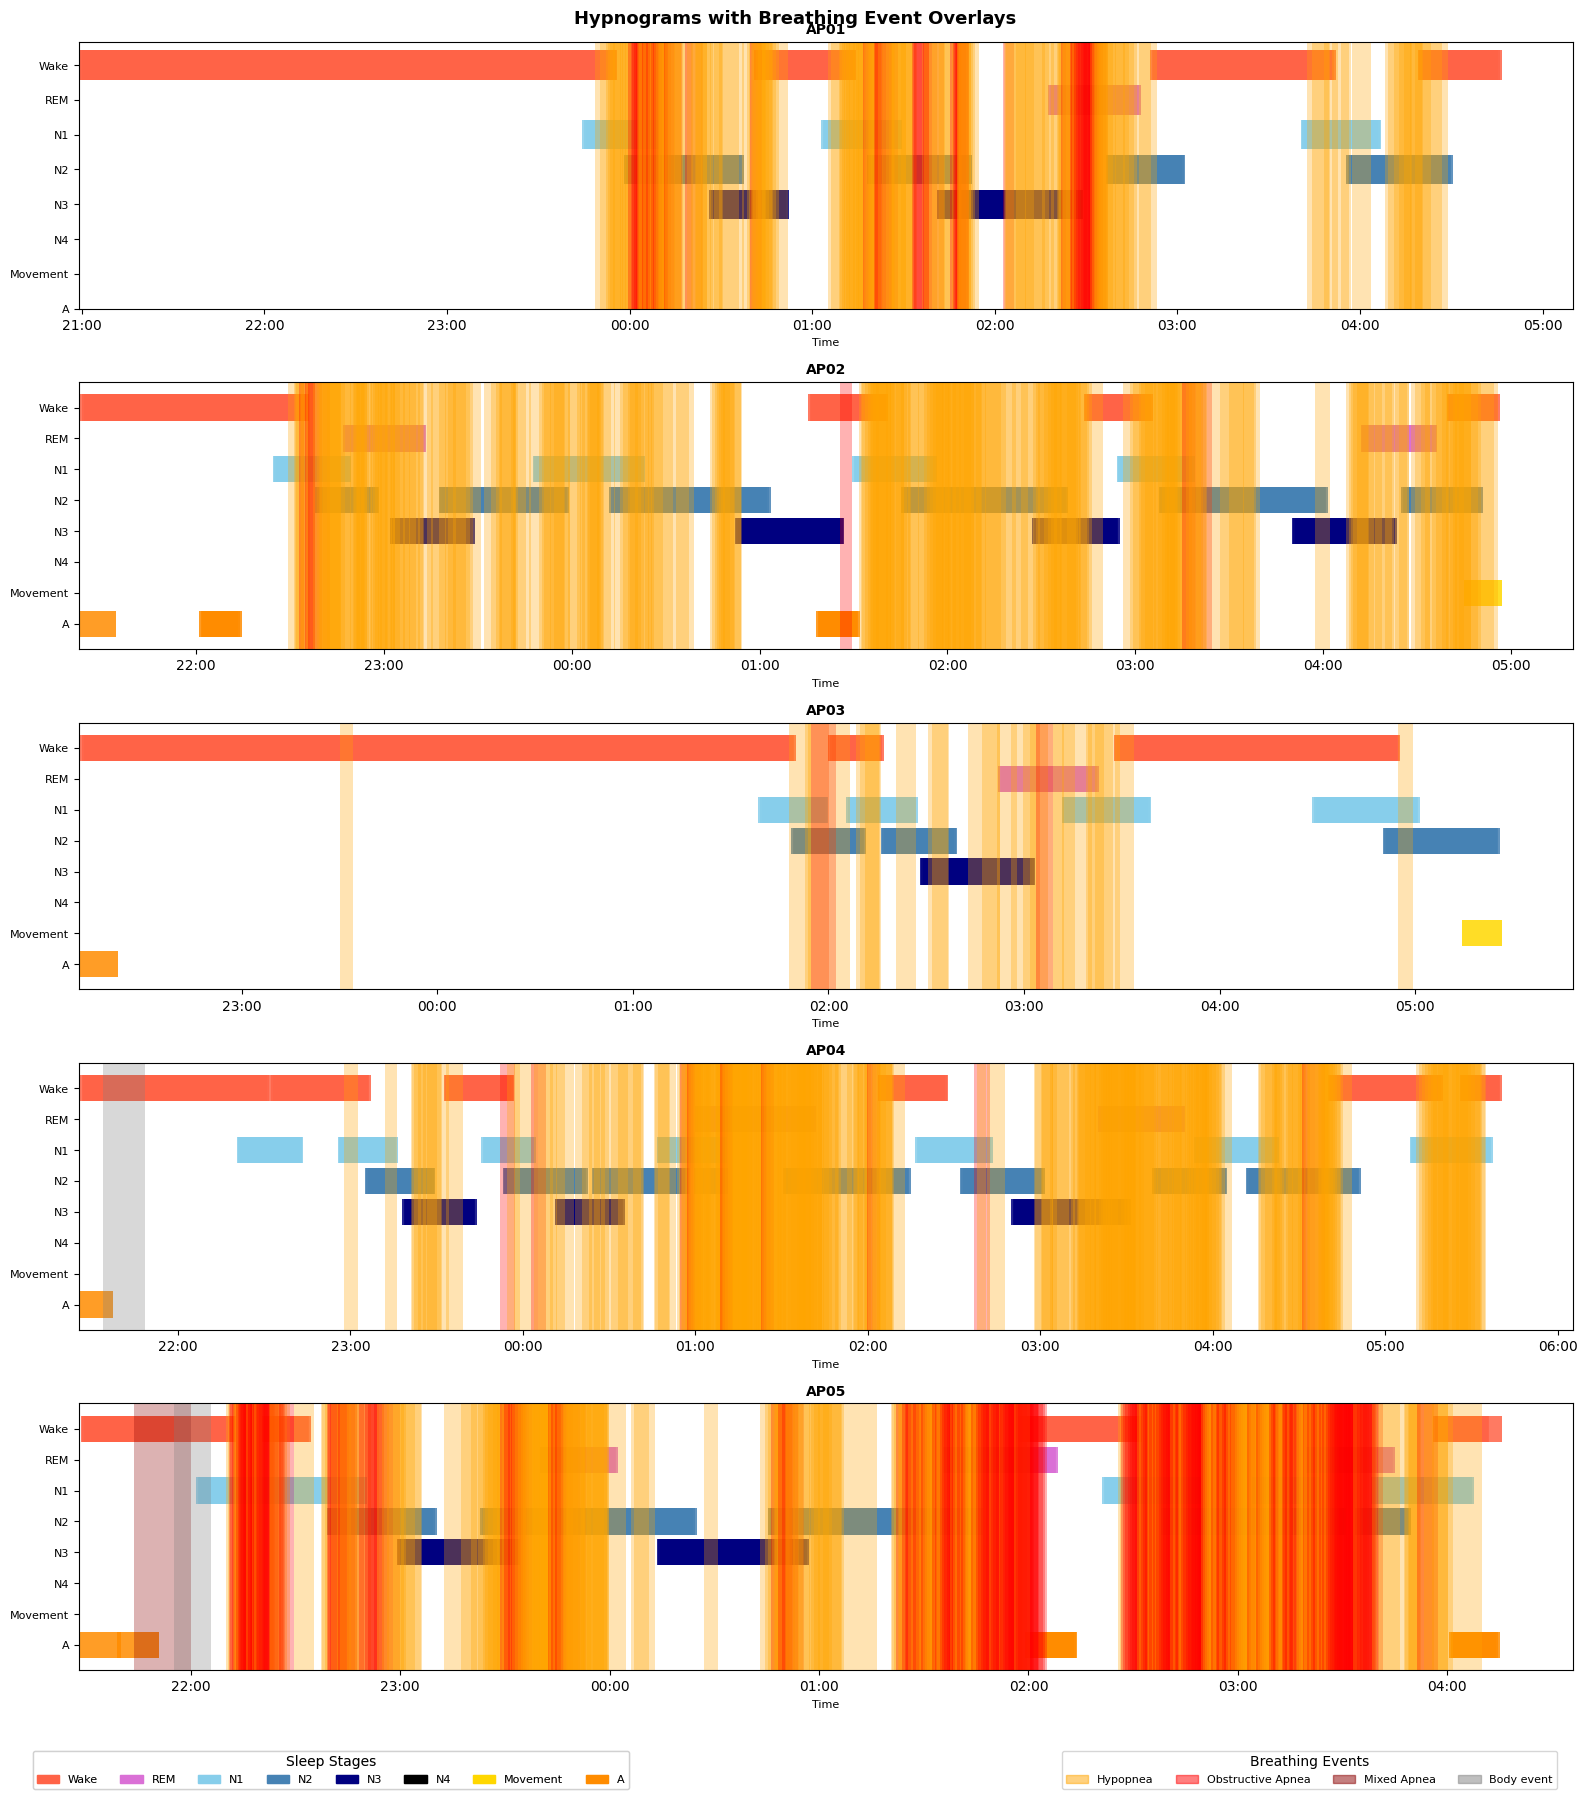

Figure saved: eda_hypnograms.png


In [12]:
#4b. Hypnogram (sleep stage timeline) per patient with event overlay

STAGE_ORDER = ['Wake', 'REM', 'N1', 'N2', 'N3', 'N4', 'Movement', 'A']
STAGE_COLOURS = {
    'Wake': 'tomato', 'REM': 'orchid', 'N1': 'skyblue',
    'N2': 'steelblue', 'N3': 'navy', 'N4': 'black',
    'Movement': 'gold', 'A': 'darkorange',
}
EVENT_COLOURS = {'Hypopnea': 'orange', 'Obstructive Apnea': 'red',
                 'Mixed Apnea': 'darkred', 'Body event': 'grey'}

fig, axes = plt.subplots(len(PATIENT_IDS), 1, figsize=(16, 3.5 * len(PATIENT_IDS)))
fig.suptitle('Hypnograms with Breathing Event Overlays', fontsize=13, fontweight='bold')

for ax, pid in zip(axes, PATIENT_IDS):
    sp = sleep_data[pid].reset_index()
    ev = event_data[pid]

    stage_y = {s: i for i, s in enumerate(reversed(STAGE_ORDER))}

    for _, epoch in sp.iterrows():
        stage = epoch['Sleep Stage']
        y_pos = stage_y.get(stage, -1)
        colour = STAGE_COLOURS.get(stage, 'lightgrey')
        ax.barh(y_pos, 30 / 3600, left=mdates.date2num(epoch['Timestamp']),
                height=0.85, color=colour, alpha=0.85, linewidth=0)

    for _, row in ev.iterrows():
        x_start = mdates.date2num(row['Start Timestamp'])
        width   = row['Duration (s)'] / 3600
        ec = EVENT_COLOURS.get(row['Event Type'], 'black')
        ax.axvspan(x_start, x_start + width, ymin=0, ymax=1,
                   color=ec, alpha=0.3, linewidth=0)

    ax.set_yticks(list(stage_y.values()))
    ax.set_yticklabels(list(reversed(STAGE_ORDER)), fontsize=8)
    ax.xaxis_date()
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax.set_title(pid, fontsize=10, fontweight='bold')
    ax.set_xlabel('Time', fontsize=8)

stage_patches = [mpatches.Patch(color=c, label=k) for k, c in STAGE_COLOURS.items()]
event_patches = [mpatches.Patch(color=c, label=k, alpha=0.5) for k, c in EVENT_COLOURS.items()]

stage_legend = fig.legend(
    handles=stage_patches, title='Sleep Stages', loc='lower left',
    ncol=len(STAGE_COLOURS), fontsize=8, bbox_to_anchor=(0.02, -0.04)
)
fig.legend(
    handles=event_patches, title='Breathing Events', loc='lower right',
    ncol=len(EVENT_COLOURS), fontsize=8, bbox_to_anchor=(0.98, -0.04)
)
fig.add_artist(stage_legend)
plt.tight_layout()
plt.savefig('eda_hypnograms.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: eda_hypnograms.png')

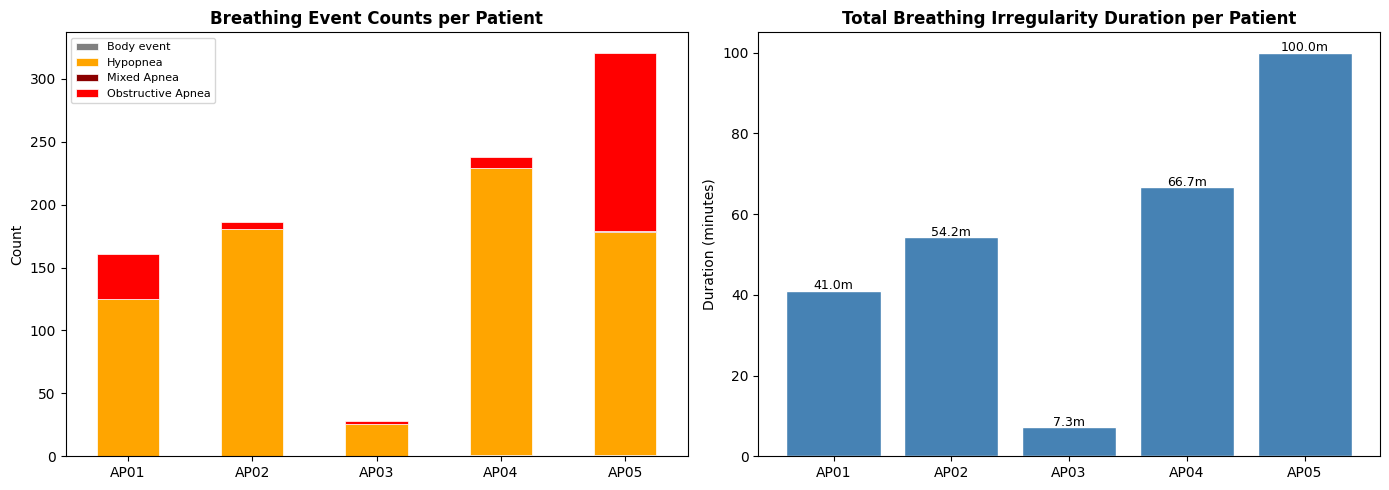

Figure saved: eda_events.png


In [13]:
# 4c. Breathing event summary per patient

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

event_summary = []
for pid in PATIENT_IDS:
    ev = event_data[pid]
    counts = ev['Event Type'].value_counts()
    for etype, cnt in counts.items():
        event_summary.append({'Patient': pid, 'Event Type': etype, 'Count': cnt})

event_summary_df = pd.DataFrame(event_summary)

# Stacked bar — event counts
pivot = event_summary_df.pivot(index='Patient', columns='Event Type', values='Count').fillna(0)
pivot.plot(kind='bar', stacked=True, ax=axes[0],
           color=[EVENT_COLOURS.get(c, 'grey') for c in pivot.columns],
           edgecolor='white', linewidth=0.5)
axes[0].set_title('Breathing Event Counts per Patient', fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(fontsize=8)

# Total event duration
total_dur = {pid: event_data[pid]['Duration (s)'].sum() / 60 for pid in PATIENT_IDS}
axes[1].bar(total_dur.keys(), total_dur.values(),
            color='steelblue', edgecolor='white')
axes[1].set_title('Total Breathing Irregularity Duration per Patient', fontweight='bold')
axes[1].set_ylabel('Duration (minutes)')
axes[1].set_xlabel('')
for pid, val in total_dur.items():
    axes[1].text(pid, val + 0.3, f'{val:.1f}m', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('eda_events.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: eda_events.png')

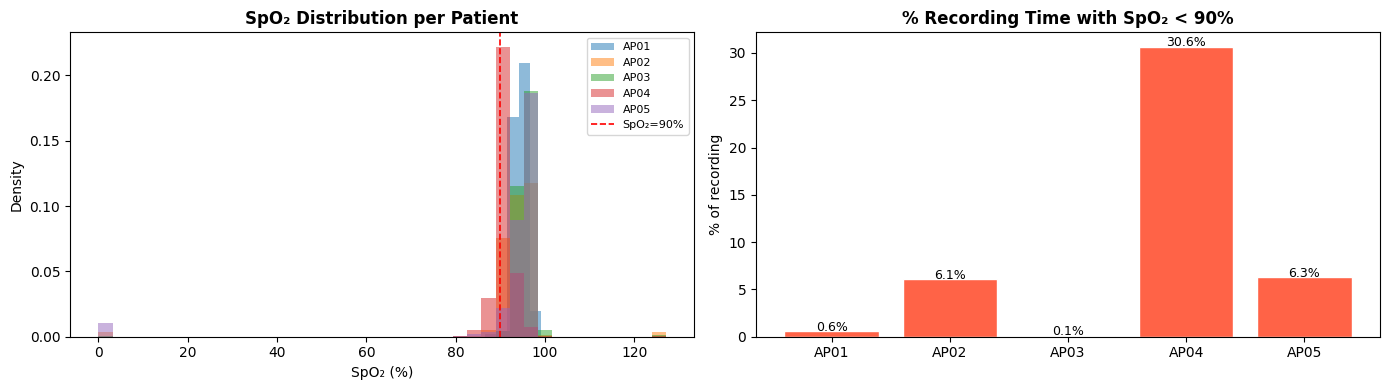

In [14]:
# 4d. SpO2 distribution and desaturation burden

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for pid in PATIENT_IDS:
    vals = spo2_data[pid]['Value'].dropna()
    axes[0].hist(vals, bins=40, alpha=0.5, label=pid, density=True)

axes[0].axvline(90, color='red', linestyle='--', linewidth=1.2, label='SpO₂=90%')
axes[0].set_title('SpO₂ Distribution per Patient', fontweight='bold')
axes[0].set_xlabel('SpO₂ (%)')
axes[0].set_ylabel('Density')
axes[0].legend(fontsize=8)

# Time below 90%
desat_pct = {}
for pid in PATIENT_IDS:
    vals = spo2_data[pid]['Value'].dropna()
    desat_pct[pid] = 100 * (vals < 90).sum() / len(vals)

axes[1].bar(desat_pct.keys(), desat_pct.values(), color='tomato', edgecolor='white')
axes[1].set_title('% Recording Time with SpO₂ < 90%', fontweight='bold')
axes[1].set_ylabel('% of recording')
for pid, val in desat_pct.items():
    axes[1].text(pid, val + 0.05, f'{val:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('eda_spo2.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Signal Resampling & Merging

All three continuous signals are resampled to a common 1-second resolution using the mean of samples in each second. Linear interpolation is applied to fill any residual gaps **after** the resample step (not before), so that no artificial values are injected into long dropout periods.

In [15]:
merged_data = {}

for pid in PATIENT_IDS:
    nasal_1s  = nasal_data[pid]['Value'].resample('1s').mean().rename('Nasal Airflow')
    thorac_1s = thorac_data[pid]['Value'].resample('1s').mean().rename('Thoracic Movement')
    spo2_1s   = spo2_data[pid]['Value'].resample('1s').mean().rename('SPO2')

    df = pd.concat([nasal_1s, thorac_1s, spo2_1s], axis=1, join='outer')

    # Report gap extent before interpolating
    n_nan_pre = df.isna().sum()
    df = df.interpolate(method='linear', limit=30)  # limit: don't interpolate gaps >30s
    n_nan_post = df.isna().sum()

    merged_data[pid] = df

    print(f'{pid}: {len(df)} seconds | '
          f'NaN before interp: {n_nan_pre.to_dict()} | '
          f'NaN after interp: {n_nan_post.to_dict()}')

print('\nAll signals resampled and merged.')

AP01: 27350 seconds | NaN before interp: {'Nasal Airflow': 0, 'Thoracic Movement': 0, 'SPO2': 0} | NaN after interp: {'Nasal Airflow': 0, 'Thoracic Movement': 0, 'SPO2': 0}
AP02: 26553 seconds | NaN before interp: {'Nasal Airflow': 0, 'Thoracic Movement': 0, 'SPO2': 0} | NaN after interp: {'Nasal Airflow': 0, 'Thoracic Movement': 0, 'SPO2': 0}
AP03: 25457 seconds | NaN before interp: {'Nasal Airflow': 0, 'Thoracic Movement': 0, 'SPO2': 0} | NaN after interp: {'Nasal Airflow': 0, 'Thoracic Movement': 0, 'SPO2': 0}
AP04: 29004 seconds | NaN before interp: {'Nasal Airflow': 0, 'Thoracic Movement': 0, 'SPO2': 0} | NaN after interp: {'Nasal Airflow': 0, 'Thoracic Movement': 0, 'SPO2': 0}
AP05: 23739 seconds | NaN before interp: {'Nasal Airflow': 0, 'Thoracic Movement': 0, 'SPO2': 0} | NaN after interp: {'Nasal Airflow': 0, 'Thoracic Movement': 0, 'SPO2': 0}

All signals resampled and merged.


## 6. Feature Engineering

Features are computed at the **patient level** since only 5 subjects are available. Each patient yields one feature vector.

### 6a. Breathing Event Features
- Total event count
- Total event duration
- Count per event type
- **Apnea-Hypopnea Index (AHI)** = (apneas + hypopneas) / total sleep time in hours — the primary clinical metric for OSA severity

### 6b. SpO2 Features
- Mean, median, minimum SpO2
- % time below 90% (T90) — oxygen desaturation index surrogate
- Oxygen Desaturation Index (ODI) at 3% threshold

### 6c. Sleep Architecture Features
- Duration and percentage per sleep stage
- Sleep efficiency = (Total Sleep Time / Time in Bed) × 100
- WASO (Wake After Sleep Onset) duration

In [16]:
# 6a. AHI computation
# Total Sleep Time (TST) excludes Wake and Movement epochs.
# Each sleep profile epoch = 30 seconds.

EPOCH_DURATION_S = 30  # seconds per sleep epoch
WAKE_STAGES      = {'Wake', 'Movement'}  # excluded from TST
APNEA_EVENTS     = {'Obstructive Apnea', 'Mixed Apnea', 'Central Apnea'}
HYPOPNEA_EVENTS  = {'Hypopnea'}

ahi_rows = []

for pid in PATIENT_IDS:
    sp = sleep_data[pid]
    ev = event_data[pid]

    # Total sleep time in hours
    sleep_epochs = sp[~sp['Sleep Stage'].isin(WAKE_STAGES)]
    tst_h = len(sleep_epochs) * EPOCH_DURATION_S / 3600

    # Count clinically scored apneas and hypopneas
    n_apneas    = ev['Event Type'].isin(APNEA_EVENTS).sum()
    n_hypopneas = ev['Event Type'].isin(HYPOPNEA_EVENTS).sum()
    ahi         = (n_apneas + n_hypopneas) / tst_h if tst_h > 0 else 0

    ahi_rows.append({
        'Patient': pid,
        'TST (h)': round(tst_h, 2),
        'N Apneas': n_apneas,
        'N Hypopneas': n_hypopneas,
        'AHI': round(ahi, 1),
    })

ahi_df = pd.DataFrame(ahi_rows).set_index('Patient')
print('AHI Summary:')
print(ahi_df)
print()
print('AHI Severity categories (AASM guidelines):')
print('  Normal  : AHI < 5')
print('  Mild OSA: 5 ≤ AHI < 15')
print('  Moderate: 15 ≤ AHI < 30')
print('  Severe  : AHI ≥ 30')

AHI Summary:
         TST (h)  N Apneas  N Hypopneas   AHI
Patient                                      
AP01        3.38        36          125  47.6
AP02        5.92         5          181  31.4
AP03        2.35         2           26  11.9
AP04        5.80         9          228  40.9
AP05        5.59       143          177  57.2

AHI Severity categories (AASM guidelines):
  Normal  : AHI < 5
  Mild OSA: 5 ≤ AHI < 15
  Moderate: 15 ≤ AHI < 30
  Severe  : AHI ≥ 30


In [19]:
# 6b–c. Full feature extraction

def compute_odi(spo2_series: pd.Series, drop_pct: float = 3.0,
                min_duration_s: float = 10.0, fs: float = 1.0) -> float:
    vals = spo2_series.dropna().values
    if len(vals) < int(min_duration_s * fs):
        return 0.0

    # Rolling maximum as local baseline (120-second window)
    baseline = pd.Series(vals).rolling(window=int(120 * fs), min_periods=1).max().values
    below    = (baseline - vals) >= drop_pct

    # Count transitions into desaturation
    events = 0
    in_event = False
    run = 0
    for b in below:
        if b:
            run += 1
            if run >= int(min_duration_s * fs) and not in_event:
                events += 1
                in_event = True
        else:
            run = 0
            in_event = False

    hours = len(vals) / (fs * 3600)
    return round(events / hours, 2) if hours > 0 else 0.0


feature_rows = []

for pid in PATIENT_IDS:
    sp  = sleep_data[pid]
    ev  = event_data[pid]
    spo2 = merged_data[pid]['SPO2'].dropna()
    nasal = merged_data[pid]['Nasal Airflow'].dropna()
    thorac = merged_data[pid]['Thoracic Movement'].dropna()

    # --- Sleep architecture ---
    total_epochs     = len(sp)
    sleep_epochs     = sp[~sp['Sleep Stage'].isin(WAKE_STAGES)]
    wake_epochs      = sp[sp['Sleep Stage'] == 'Wake']
    tst_s            = len(sleep_epochs) * EPOCH_DURATION_S
    tib_s            = total_epochs * EPOCH_DURATION_S
    sleep_efficiency = 100 * tst_s / tib_s if tib_s > 0 else 0

    # WASO: Wake epochs after first sleep onset
    first_sleep_idx = sp[~sp['Sleep Stage'].isin(WAKE_STAGES)].index
    if len(first_sleep_idx) > 0:
        waso_epochs = wake_epochs[wake_epochs.index > first_sleep_idx[0]]
        waso_s      = len(waso_epochs) * EPOCH_DURATION_S
    else:
        waso_s = 0

    stage_counts = sp['Sleep Stage'].value_counts()
    stage_dur    = {s: stage_counts.get(s, 0) * EPOCH_DURATION_S for s in
                    ['N1', 'N2', 'N3', 'N4', 'REM', 'Wake', 'Movement', 'A']}
    stage_pct    = {f'Pct_{s}': 100 * stage_dur[s] / tib_s if tib_s > 0 else 0
                    for s in stage_dur}

    # --- Breathing events ---
    n_apneas     = ev['Event Type'].isin(APNEA_EVENTS).sum()
    n_hypopneas  = ev['Event Type'].isin(HYPOPNEA_EVENTS).sum()
    tst_h        = tst_s / 3600
    ahi          = (n_apneas + n_hypopneas) / tst_h if tst_h > 0 else 0
    mean_event_dur = ev['Duration (s)'].mean() if len(ev) else 0
    max_event_dur  = ev['Duration (s)'].max()  if len(ev) else 0

    # --- SpO2 features ---
    t90  = 100 * (spo2 < 90).sum() / len(spo2) if len(spo2) else 0
    odi  = compute_odi(spo2, drop_pct=3.0, min_duration_s=10.0, fs=1.0)

    # --- Signal variability ---
    nasal_std  = nasal.std()
    thorac_std = thorac.std()

    row = {
        'Patient':            pid,
        # Breathing events
        'AHI':                round(ahi, 2),
        'N_Apneas':           int(n_apneas),
        'N_Hypopneas':        int(n_hypopneas),
        'N_Events_Total':     len(ev),
        'Mean_Event_Dur_s':   round(mean_event_dur, 2),
        'Max_Event_Dur_s':    round(max_event_dur, 2),
        # SpO2
        'SpO2_Mean':          round(spo2.mean(), 2),
        'SpO2_Median':        round(spo2.median(), 2),
        'SpO2_Min':           round(spo2.min(), 2),
        'T90_Pct':            round(t90, 3),
        'ODI3':               odi,
        # Sleep architecture
        'TST_h':              round(tst_h, 2),
        'Sleep_Efficiency':   round(sleep_efficiency, 2),
        'WASO_min':           round(waso_s / 60, 1),
        **{f'Dur_{s}_s': stage_dur[s] for s in stage_dur},
        **stage_pct,
        # Signal variability
        'Nasal_Std':          round(nasal_std, 3),
        'Thorac_Std':         round(thorac_std, 3),
    }
    feature_rows.append(row)

features_df = pd.DataFrame(feature_rows).set_index('Patient')
print('Feature matrix shape:', features_df.shape)
print(features_df[['AHI', 'N_Apneas', 'N_Hypopneas', 'SpO2_Mean',
                    'SpO2_Min', 'T90_Pct', 'ODI3',
                    'TST_h', 'Sleep_Efficiency', 'WASO_min']].to_string())

Feature matrix shape: (5, 32)
           AHI  N_Apneas  N_Hypopneas  SpO2_Mean  SpO2_Min  T90_Pct   ODI3  TST_h  Sleep_Efficiency  WASO_min
Patient                                                                                                      
AP01     47.59        36          125      94.65      47.5    0.629  12.24   3.38             44.52      87.5
AP02     31.39         5          181      93.58       0.0    6.338  17.35   5.92             80.25      87.0
AP03     11.91         2           26      95.89       0.0    0.134  22.06   2.35             33.18     283.5
AP04     40.86         9          228      90.63       0.0   32.637  27.55   5.80             71.98     135.5
AP05     57.23       143          177      92.20       0.0    6.454  37.61   5.59             84.72      60.5


## 7. Clinical Severity Labelling (AHI-based)

Labels are assigned according to **AASM (American Academy of Sleep Medicine)** guidelines:

| AHI (events/h) | Category |
|---|---|
| < 5 | Normal / No OSA |
| 5 – 14.9 | Mild OSA |
| 15 – 29.9 | Moderate OSA |
| ≥ 30 | Severe OSA |


Patient AHI and Clinical Labels:
           AHI AHI_Severity  OSA_Significant
Patient                                     
AP01     47.59   Severe OSA                1
AP02     31.39   Severe OSA                1
AP03     11.91     Mild OSA                0
AP04     40.86   Severe OSA                1
AP05     57.23   Severe OSA                1

Class distribution (OSA_Significant):
OSA_Significant
Mod/Severe (1)     4
Normal/Mild (0)    1


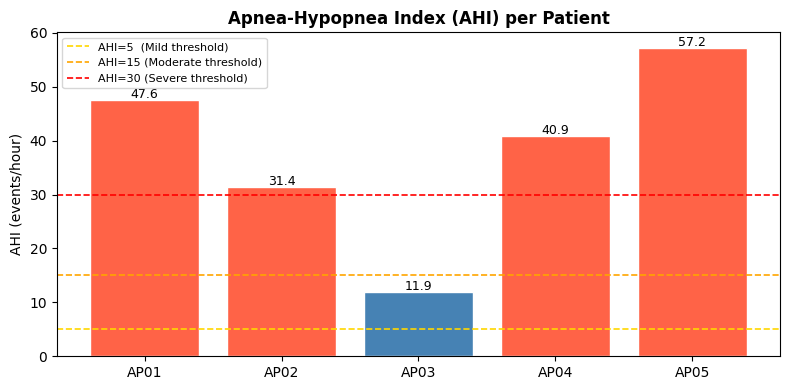

In [20]:
def ahi_severity_label(ahi: float) -> str:
    if ahi < 5:
        return 'Normal'
    elif ahi < 15:
        return 'Mild OSA'
    elif ahi < 30:
        return 'Moderate OSA'
    else:
        return 'Severe OSA'

def ahi_binary_label(ahi: float, threshold: float = 15.0) -> int:
    return int(ahi >= threshold)

features_df['AHI_Severity']    = features_df['AHI'].apply(ahi_severity_label)
features_df['OSA_Significant'] = features_df['AHI'].apply(ahi_binary_label)

print('Patient AHI and Clinical Labels:')
print(features_df[['AHI', 'AHI_Severity', 'OSA_Significant']].to_string())

# Class balance
print(f'\nClass distribution (OSA_Significant):')
print(features_df['OSA_Significant'].value_counts().rename({0: 'Normal/Mild (0)', 1: 'Mod/Severe (1)'})
      .to_string())

# Visual — AHI bar chart with threshold lines
fig, ax = plt.subplots(figsize=(8, 4))
colours = ['tomato' if v >= 15 else 'steelblue' for v in features_df['AHI']]
ax.bar(features_df.index, features_df['AHI'], color=colours, edgecolor='white')
ax.axhline(5,  color='gold',   linestyle='--', linewidth=1.2, label='AHI=5  (Mild threshold)')
ax.axhline(15, color='orange', linestyle='--', linewidth=1.2, label='AHI=15 (Moderate threshold)')
ax.axhline(30, color='red',    linestyle='--', linewidth=1.2, label='AHI=30 (Severe threshold)')
for pid, row in features_df.iterrows():
    ax.text(pid, row['AHI'] + 0.3, f"{row['AHI']:.1f}", ha='center', fontsize=9)
ax.set_title('Apnea-Hypopnea Index (AHI) per Patient', fontweight='bold')
ax.set_ylabel('AHI (events/hour)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('ahi_severity.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Classification Model

**Task:** Predict whether a patient has clinically significant OSA (AHI ≥ 15) from their physiological features.

**Validation strategy:** Leave-One-Out Cross-Validation (LOOCV)  
With only 5 patients, LOOCV is the appropriate strategy. It trains on 4 patients and tests on 1, repeated for each patient. This avoids data leakage and is the standard approach for very small clinical datasets.

**Model:** Random Forest Classifier with StandardScaler preprocessing.  


In [21]:
# Feature columns — exclude label columns and any features derived directly from AHI
EXCLUDE_COLS = ['AHI', 'AHI_Severity', 'OSA_Significant',
                'N_Apneas', 'N_Hypopneas', 'N_Events_Total']  # AHI components -> leakage

feature_cols = [c for c in features_df.columns if c not in EXCLUDE_COLS]

X = features_df[feature_cols].values
y = features_df['OSA_Significant'].values
patient_ids = features_df.index.tolist()

print(f'Feature matrix: {X.shape[0]} patients × {X.shape[1]} features')
print(f'Features used: {feature_cols}')
print(f'Labels: {dict(zip(patient_ids, y))}')
print()

# Pipeline: scale then classify
clf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    RandomForestClassifier(n_estimators=100, random_state=42, max_depth=3)),
])

# LOOCV
loo     = LeaveOneOut()
y_pred  = cross_val_predict(clf_pipeline, X, y, cv=loo)

print('LOOCV Predictions vs Ground Truth:')
for pid, true, pred in zip(patient_ids, y, y_pred):
    outcome = 'CORRECT' if true == pred else 'WRONG'
    print(f'  {pid}: true={true}, predicted={pred}  [{outcome}]')

print()
acc  = accuracy_score(y, y_pred)
prec = precision_score(y, y_pred, zero_division=0)
rec  = recall_score(y, y_pred, zero_division=0)
f1   = f1_score(y, y_pred, zero_division=0)

print('LOOCV Performance (N=5 — DEMONSTRATION ONLY):')
print(f'  Accuracy : {acc:.2f}  ({int(acc*5)}/5 correct)')
print(f'  Precision: {prec:.2f}')
print(f'  Recall   : {rec:.2f}')
print(f'  F1-Score : {f1:.2f}')
print()
print('Confusion Matrix:')
cm = confusion_matrix(y, y_pred)
print(pd.DataFrame(cm,
                   index=['True Normal/Mild', 'True Mod/Severe'],
                   columns=['Pred Normal/Mild', 'Pred Mod/Severe']))
print()

Feature matrix: 5 patients × 28 features
Features used: ['Mean_Event_Dur_s', 'Max_Event_Dur_s', 'SpO2_Mean', 'SpO2_Median', 'SpO2_Min', 'T90_Pct', 'ODI3', 'TST_h', 'Sleep_Efficiency', 'WASO_min', 'Dur_N1_s', 'Dur_N2_s', 'Dur_N3_s', 'Dur_N4_s', 'Dur_REM_s', 'Dur_Wake_s', 'Dur_Movement_s', 'Dur_A_s', 'Pct_N1', 'Pct_N2', 'Pct_N3', 'Pct_N4', 'Pct_REM', 'Pct_Wake', 'Pct_Movement', 'Pct_A', 'Nasal_Std', 'Thorac_Std']
Labels: {'AP01': np.int64(1), 'AP02': np.int64(1), 'AP03': np.int64(0), 'AP04': np.int64(1), 'AP05': np.int64(1)}

LOOCV Predictions vs Ground Truth:
  AP01: true=1, predicted=0  [WRONG]
  AP02: true=1, predicted=1  [CORRECT]
  AP03: true=0, predicted=1  [WRONG]
  AP04: true=1, predicted=1  [CORRECT]
  AP05: true=1, predicted=1  [CORRECT]

LOOCV Performance (N=5 — DEMONSTRATION ONLY):
  Accuracy : 0.60  (3/5 correct)
  Precision: 0.75
  Recall   : 0.75
  F1-Score : 0.75

Confusion Matrix:
                  Pred Normal/Mild  Pred Mod/Severe
True Normal/Mild                 0     

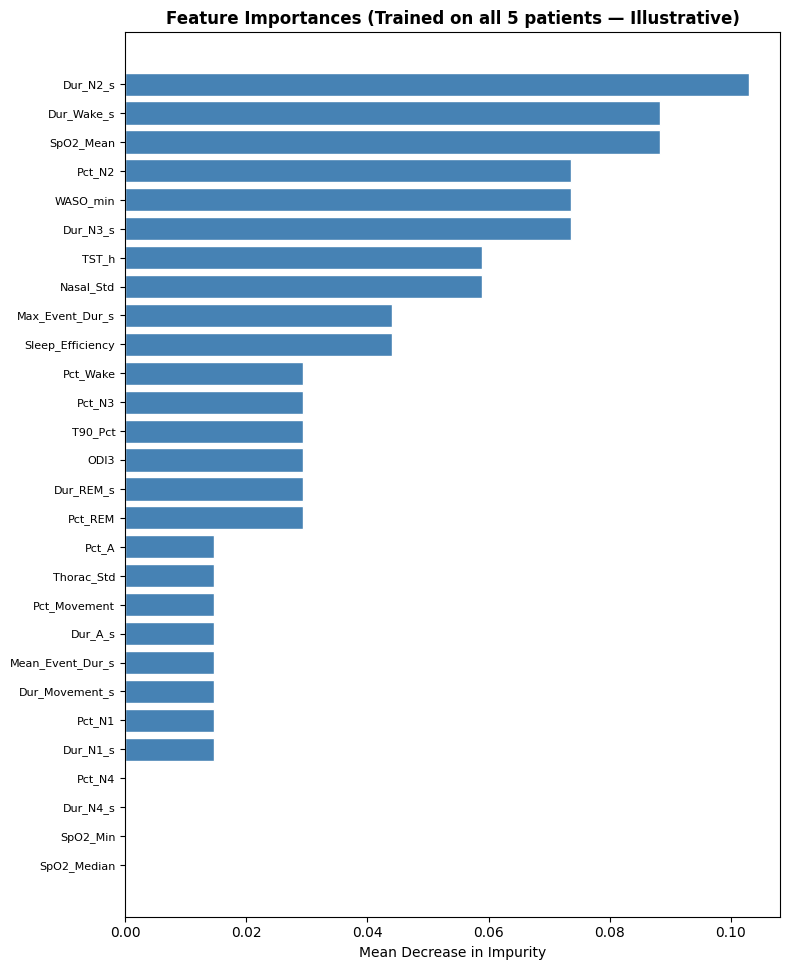

In [22]:
# Feature importance
clf_pipeline.fit(X, y)
importances = clf_pipeline.named_steps['clf'].feature_importances_

imp_df = pd.DataFrame({'Feature': feature_cols, 'Importance': importances})
imp_df = imp_df.sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, max(4, len(feature_cols) * 0.35)))
ax.barh(imp_df['Feature'], imp_df['Importance'], color='steelblue', edgecolor='white')
ax.set_xlabel('Mean Decrease in Impurity')
ax.set_title('Feature Importances (Trained on all 5 patients — Illustrative)',
             fontweight='bold')
ax.tick_params(axis='y', labelsize=8)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Clinical Summary & Interpretation

In [23]:
print('=' * 70)
print('CLINICAL SUMMARY REPORT')
print('=' * 70)

summary_cols = ['AHI', 'AHI_Severity', 'TST_h', 'Sleep_Efficiency',
                'WASO_min', 'SpO2_Mean', 'SpO2_Min', 'T90_Pct', 'ODI3']
print(features_df[summary_cols].to_string())

print()
print('Key findings:')
for pid, row in features_df.iterrows():
    print(f'  {pid} ({row["AHI_Severity"]}, AHI={row["AHI"]:.1f}): '
          f'TST={row["TST_h"]:.1f}h, '
          f'Efficiency={row["Sleep_Efficiency"]:.0f}%, '
          f'Min SpO₂={row["SpO2_Min"]:.0f}%, '
          f'T90={row["T90_Pct"]:.1f}%, '
          f'ODI3={row["ODI3"]}')

print()
print('Notes:')
print('  - Sleep stage "A" (Arousal) observed in AP02–AP05 but absent from')
print('    documented Events list; retained as valid stage in analyses.')
print('  - AHI thresholds follow AASM 2012 guidelines.')
print('  - ODI3 computed using simplified rolling-baseline method;')
print('    clinical ODI requires event-by-event baseline computation.')

CLINICAL SUMMARY REPORT
           AHI AHI_Severity  TST_h  Sleep_Efficiency  WASO_min  SpO2_Mean  SpO2_Min  T90_Pct   ODI3
Patient                                                                                            
AP01     47.59   Severe OSA   3.38             44.52      87.5      94.65      47.5    0.629  12.24
AP02     31.39   Severe OSA   5.92             80.25      87.0      93.58       0.0    6.338  17.35
AP03     11.91     Mild OSA   2.35             33.18     283.5      95.89       0.0    0.134  22.06
AP04     40.86   Severe OSA   5.80             71.98     135.5      90.63       0.0   32.637  27.55
AP05     57.23   Severe OSA   5.59             84.72      60.5      92.20       0.0    6.454  37.61

Key findings:
  AP01 (Severe OSA, AHI=47.6): TST=3.4h, Efficiency=45%, Min SpO₂=48%, T90=0.6%, ODI3=12.24
  AP02 (Severe OSA, AHI=31.4): TST=5.9h, Efficiency=80%, Min SpO₂=0%, T90=6.3%, ODI3=17.35
  AP03 (Mild OSA, AHI=11.9): TST=2.4h, Efficiency=33%, Min SpO₂=0%, T90=0.1%, 